# Airbnb Data Analysis – Skopje

## Introduction

This project analyzes Airbnb listings in Skopje,
North Macedonia.

The main goal is to investigate the relationship
between price, location, property characteristics,
ratings, reviews and host characteristics.

The analysis includes data collection, data cleaning,
statistical analysis and graphical visualization.

The final results are presented using tables,
statistical measures, graphs and an interactive map.

## Research Questions

The analysis focuses on the following questions:

1. What is the typical nightly price of an Airbnb
   listing in Skopje?

2. Which types of accommodation are the most
   expensive?

3. Does a higher price correspond to a higher rating?

4. Do Superhosts have better ratings than
   non-Superhosts?

5. Is there a relationship between the number
   of reviews and the rating?

6. How does guest capacity affect the price?

7. Which neighbourhoods have the highest average
   Airbnb prices?

8. Which listings provide the best combination
   of price and rating?

## Data Source

The dataset contains Airbnb listings from Skopje,
North Macedonia.

The data was obtained from Doorstep Analytics:

https://doorstepanalytics.com/report?country=North_Macedonia&location=Skopje

The original dataset contains 2,398 listings
and 68 variables.

The dataset includes information about:

- listing characteristics
- prices
- location
- reviews
- ratings
- hosts
- availability
- property types

In [47]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("..")

from src.analysis import (
    dataset_overview,
    price_statistics,
    rating_statistics,
    price_by_room_type,
    price_by_neighbourhood,
    host_analysis,
    correlation_analysis,
    best_value_listings,
)

## Loading the Cleaned Dataset

The cleaned dataset is used for the main analysis.

The raw dataset is preserved separately so that the
original data remains unchanged.

In [48]:
DATA_FILE = (
    Path("..")
    / "data"
    / "processed"
    / "skopje_airbnb_clean.csv"
)

df = pd.read_csv(DATA_FILE)

df.head()

,country,location,airbnb_listingid,scrape_date,lat,lng,mapmarkertype,city,listingtitle,bathrooms,...,availableoverthantwoweeks,availableover30days,availableover90days,availableover180days,availablemorethan30days,availablemorethan90days,availablemorethan180days,recordinserted,price_per_guest,price_per_bedroom
0,North Macedonia,Skopje,1319102079355699997,2026-03-25 00:07:59,41.97570,21.45350,EXACT,Skopje,Nest Away Apartments | The Pacific Blue,1.0,...,1,1,1,1,1,1,1,2026-03-25 00:07:59.000000,12.526667,37.58
1,North Macedonia,Skopje,1322219834786176003,2026-03-24 22:36:35,41.99291,21.44677,APPROX,Skopje,Bed in 6 bedroom mix dormitory,1.0,...,1,1,1,1,1,1,1,2026-03-24 22:36:35.000000,1.956667,NaN
2,North Macedonia,Skopje,1335613944347624852,2026-03-25 01:14:20,41.98863,21.44605,APPROX,Skopje,Urban nest,1.0,...,1,1,1,0,1,1,0,2026-03-25 01:14:20.000000,14.876667,44.63
3,North Macedonia,Skopje,1342986412908860805,2026-03-25 01:36:23,41.98420,21.43460,EXACT,Skopje,Sweet Home Skopje,1.0,...,1,1,1,1,1,1,1,2026-03-25 01:36:23.000000,12.332500,49.33
4,North Macedonia,Skopje,1567401526242802565,2026-03-25 00:46:37,41.99010,21.43070,EXACT,Skopje,Cozy Suite Among the Highest Floors • Free Par...,1.0,...,1,1,1,1,1,1,1,2026-03-25 00:46:37.000000,41.695000,83.39


## Dataset Overview

After the cleaning process, the dataset contains
2,148 Airbnb listings and 70 variables.

The cleaning process removed invalid and extreme
price observations and created two additional
variables:

- price_per_guest
- price_per_bedroom

In [49]:
print(f"Number of listings: {len(df):,}")
print(f"Number of variables: {len(df.columns)}")

Number of listings: 2,148
Number of variables: 70


## Basic Statistics

The following statistics provide an overview of
the Airbnb market in Skopje.

In [50]:
overview = dataset_overview(df)

overview

{'listings': 2148,
 'columns': 70,
 'average_price': np.float64(56.26559590316574),
 'median_price': np.float64(52.85),
 'average_rating': np.float64(4.781073697585769),
 'average_reviews': np.float64(26.99441340782123)}

In [51]:
summary = pd.DataFrame({
    "Metric": [
        "Number of listings",
        "Number of variables",
        "Average price (USD)",
        "Median price (USD)",
        "Average rating",
        "Average number of reviews",
    ],
    "Value": [
        overview["listings"],
        overview["columns"],
        round(overview["average_price"], 2),
        round(overview["median_price"], 2),
        round(overview["average_rating"], 2),
        round(overview["average_reviews"], 2),
    ],
})

summary

,Metric,Value
0,Number of listings,2148.00
1,Number of variables,70.00
2,Average price (USD),56.27
3,Median price (USD),52.85
4,Average rating,4.78
5,Average number of reviews,26.99


## Price Analysis

Price is one of the most important variables in
the dataset.

The analysis examines the distribution of nightly
prices and also considers price per guest and
price per bedroom.

In [52]:
price_stats = price_statistics(df)

price_stats

,basicnightprice_usd,price_per_guest,price_per_bedroom
count,2148.000000,2148.000000,2016.000000
mean,56.265596,17.191641,45.686259
std,18.569113,7.793342,17.936939
min,11.740000,1.101250,1.762000
25%,43.450000,11.745000,33.470000
50%,52.850000,15.267500,43.455000
75%,68.120000,20.555000,55.200000
max,113.920000,83.390000,110.400000


### Distribution of Airbnb Prices

The histogram shows how nightly prices are distributed
among Airbnb listings in Skopje.

Most listings are concentrated in the lower and
middle price range, while fewer listings have
higher prices.

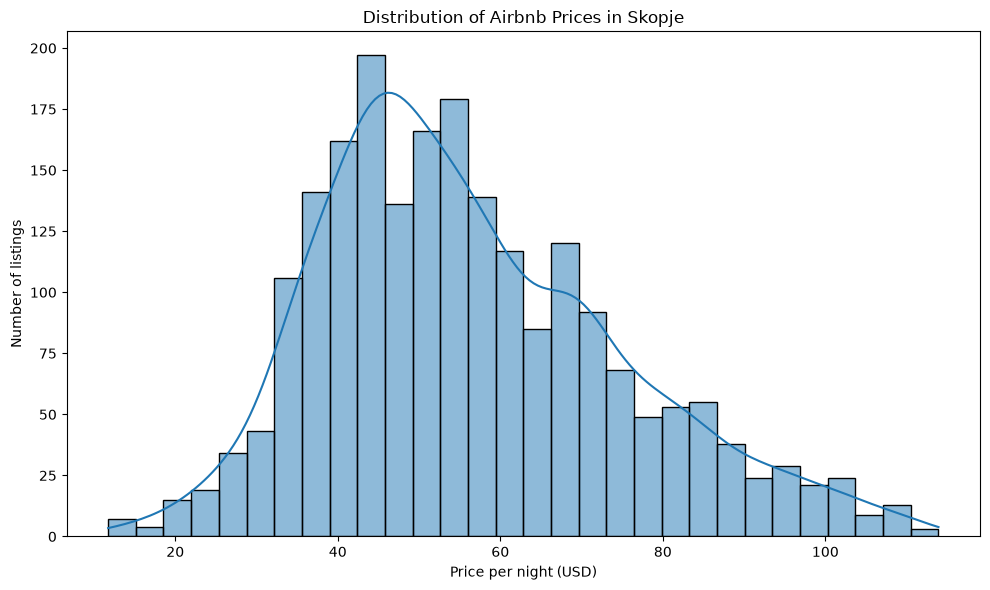

In [53]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="basicnightprice_usd",
    bins=30,
    kde=True,
)

plt.title(
    "Distribution of Airbnb Prices in Skopje"
)
plt.xlabel("Price per night (USD)")
plt.ylabel("Number of listings")

plt.tight_layout()
plt.show()

### Price by Room Type

The next analysis compares average and median
prices across different room types.

In [54]:
room_prices = price_by_room_type(df)

room_prices

,listings,average_price,median_price,average_rating
roomtype_clean,,,,
Serviced Apartment,37,64.753243,61.07,4.631875
Hotel,42,62.525238,65.18,4.248571
Entire Home,1925,57.050514,54.02,4.797129
Private Room,137,43.171679,41.11,4.598636
Shared Room,7,14.258571,14.09,4.930000


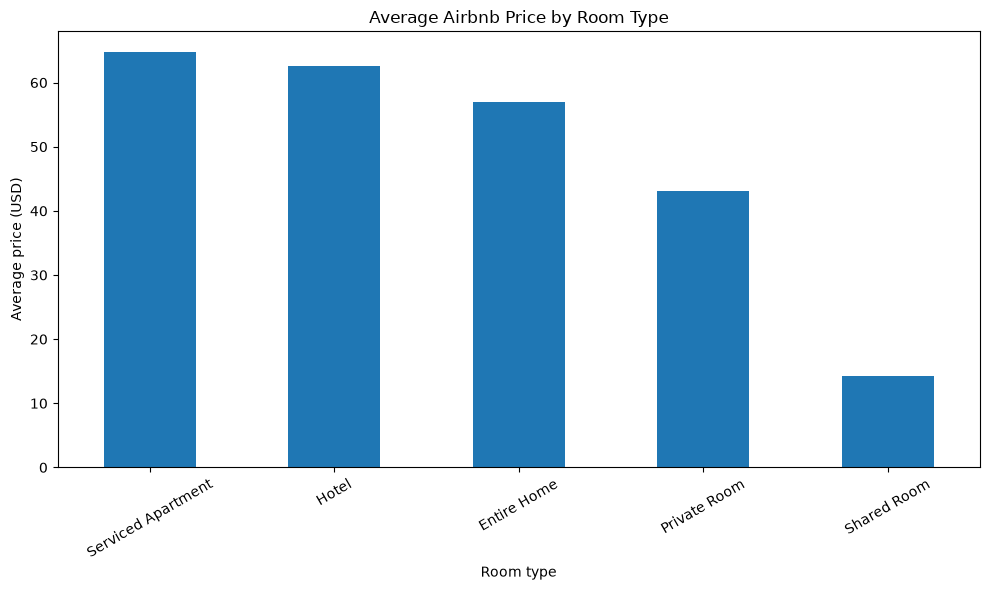

In [55]:
plt.figure(figsize=(10, 6))

room_prices["average_price"].sort_values(
    ascending=False
).plot(kind="bar")

plt.title(
    "Average Airbnb Price by Room Type"
)
plt.xlabel("Room type")
plt.ylabel("Average price (USD)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Rating Analysis

Ratings provide information about guest satisfaction.

The dataset contains an overall star rating as well
as separate ratings for location, cleanliness, value,
accuracy, check-in and communication.

In [56]:
rating_stats = rating_statistics(df)

rating_stats

,starrating,locationrating,cleanlinessrating,valuerating,accuracyrating,checkinrating,communicationrating
count,1574.000000,1574.000000,1574.000000,1574.000000,1574.000000,1574.000000,1574.000000
mean,4.781074,4.790121,4.737294,4.781086,4.812681,4.846690,4.871963
std,0.439835,0.342893,0.471636,0.431319,0.438677,0.392253,0.381905
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4.760000,4.730000,4.670000,4.770000,4.810000,4.860000,4.910000
50%,4.920000,4.880000,4.890000,4.910000,4.950000,4.970000,5.000000
75%,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


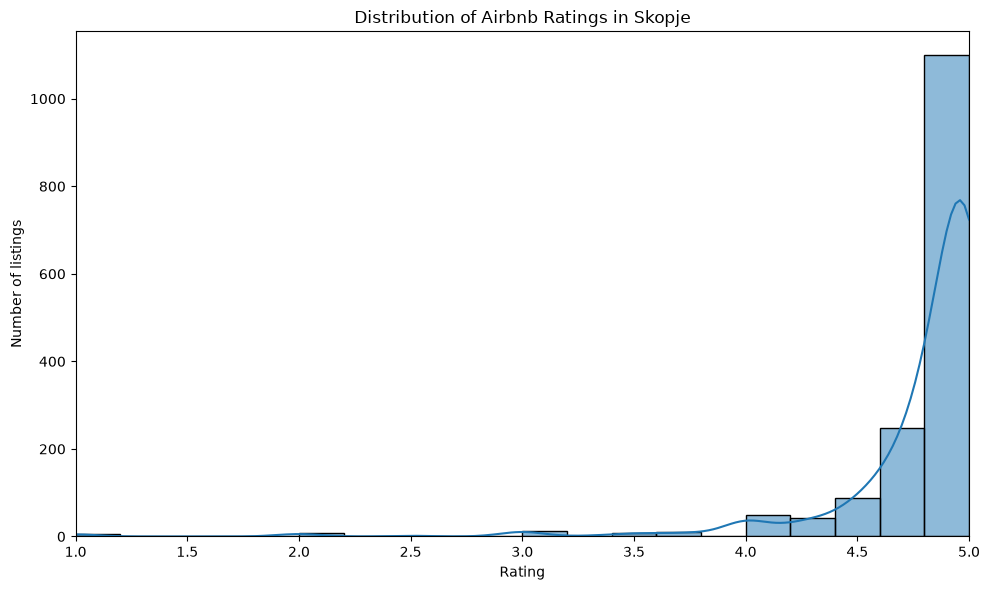

In [57]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="starrating",
    bins=20,
    kde=True,
)

plt.title(
    "Distribution of Airbnb Ratings in Skopje"
)
plt.xlabel("Rating")
plt.ylabel("Number of listings")

plt.xlim(1, 5)

plt.tight_layout()
plt.show()

## Relationship Between Price and Rating

One of the main questions is whether more expensive
Airbnb listings receive better ratings.

The correlation calculated from the dataset is
approximately 0.007, which indicates an almost
non-existent linear relationship between price
and overall rating.

In [58]:
correlation = (
    df[
        [
            "basicnightprice_usd",
            "starrating",
        ]
    ]
    .corr()
)

correlation

,basicnightprice_usd,starrating
basicnightprice_usd,1.000000,0.006977
starrating,0.006977,1.000000


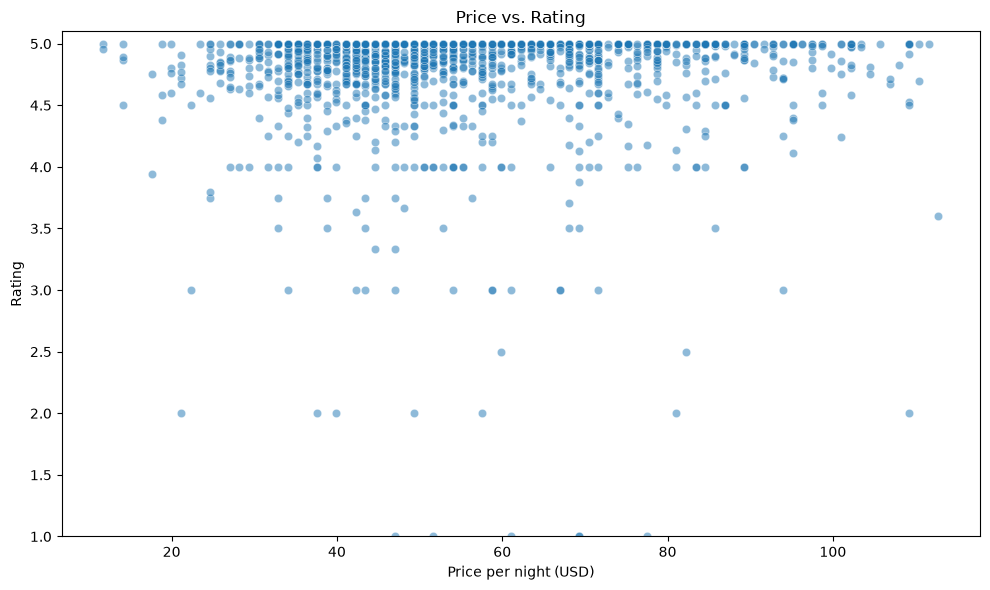

In [59]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="basicnightprice_usd",
    y="starrating",
    alpha=0.5,
)

plt.title(
    "Price vs. Rating"
)
plt.xlabel("Price per night (USD)")
plt.ylabel("Rating")

plt.ylim(1, 5.1)

plt.tight_layout()
plt.show()

### Interpretation

The scatter plot does not show a strong relationship
between price and rating.

This is consistent with the correlation coefficient,
which is close to zero.

Therefore, within this dataset, a higher nightly price
does not necessarily imply a higher guest rating.

## Superhost Analysis

Airbnb identifies some hosts as Superhosts based on their
hosting performance and guest experience.

We compare Superhosts and non-Superhosts in terms of:

- number of listings
- average price
- average rating
- average number of reviews

The goal is to determine whether Superhost status is
associated with better guest ratings and more reviews.

In [60]:
superhost_results = host_analysis(df)

superhost_results

,listings,average_price,average_rating,average_reviews
host_issuperhost,,,,
False,1508,56.831240,4.702797,13.697613
True,640,54.932797,4.906446,58.325000


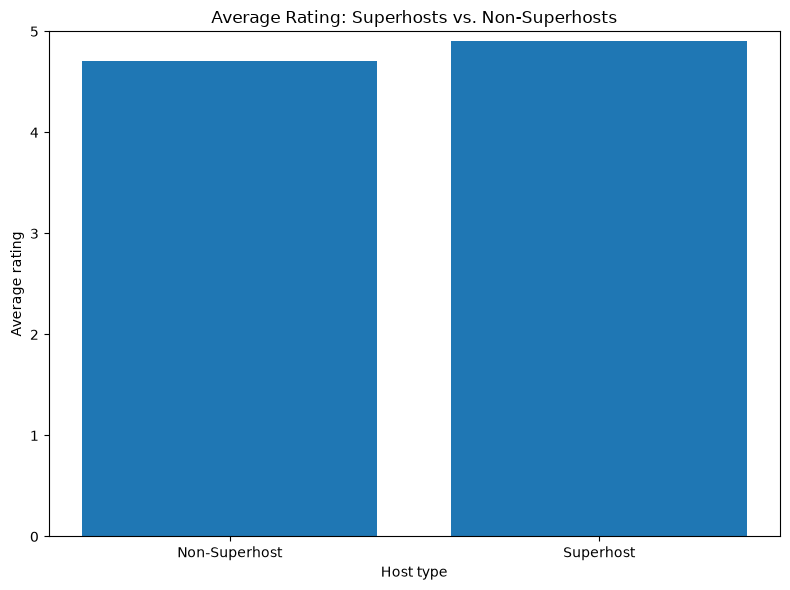

In [61]:
plt.figure(figsize=(8, 6))

superhost_rating = (
    df.groupby("host_issuperhost")["starrating"]
    .mean()
)

labels = ["Non-Superhost", "Superhost"]

values = [
    superhost_rating.get(False),
    superhost_rating.get(True),
]

plt.bar(labels, values)

plt.title(
    "Average Rating: Superhosts vs. Non-Superhosts"
)
plt.xlabel("Host type")
plt.ylabel("Average rating")
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

### Interpretation

Superhosts have a higher average rating than non-Superhosts.

In the cleaned dataset, Superhosts have an average rating
of approximately 4.91, compared with approximately 4.70
for non-Superhosts.

Superhosts also have substantially more reviews on average.
Interestingly, their average nightly price is slightly lower.

This suggests that Superhost status is associated with
better guest ratings and greater guest activity, although
this analysis does not prove that Superhost status directly
causes higher ratings.

## Reviews and Ratings

The number of reviews can provide an indication of the
popularity and activity of a listing.

We investigate whether listings with more reviews tend
to have higher ratings.

In [62]:
reviews_rating_corr = (
    df[
        ["reviewcount", "starrating"]
    ]
    .corr()
)

reviews_rating_corr

,reviewcount,starrating
reviewcount,1.000000,0.093442
starrating,0.093442,1.000000


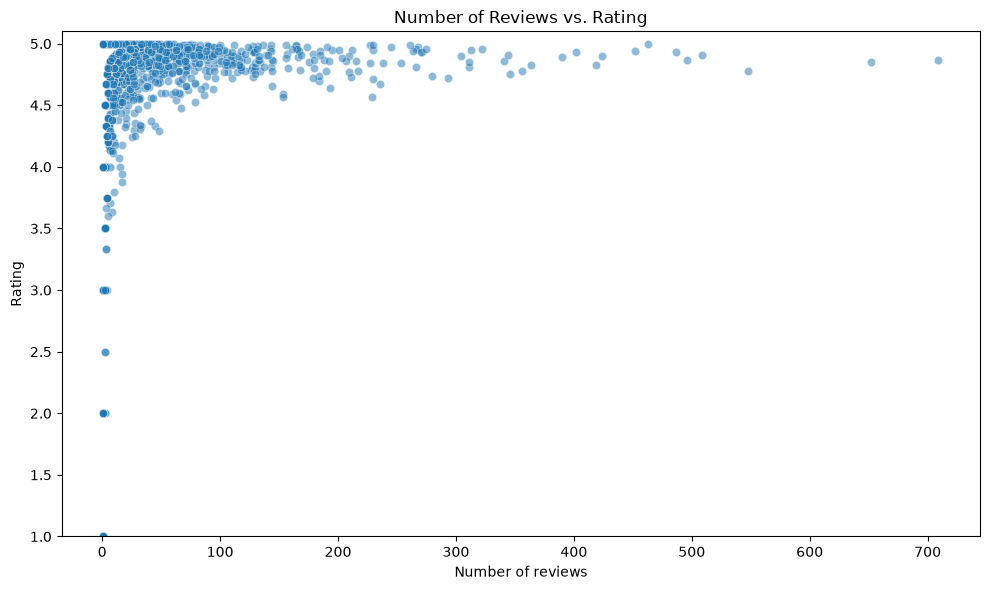

In [63]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="reviewcount",
    y="starrating",
    alpha=0.5,
)

plt.title(
    "Number of Reviews vs. Rating"
)
plt.xlabel("Number of reviews")
plt.ylabel("Rating")
plt.ylim(1, 5.1)

plt.tight_layout()
plt.show()

### Interpretation

The relationship between the number of reviews and the
overall rating is relatively weak.

A large number of reviews does not automatically mean
that a listing has a higher rating.

However, listings with many reviews can be interpreted
as more established or frequently booked properties.

## Price and Guest Capacity

Larger Airbnb properties can accommodate more guests and
may therefore have higher nightly prices.

We examine the relationship between the maximum guest
capacity and the nightly price.

In [64]:
capacity_price_corr = (
    df[
        [
            "personcapacity",
            "basicnightprice_usd",
        ]
    ]
    .corr()
)

capacity_price_corr

,personcapacity,basicnightprice_usd
personcapacity,1.000000,0.296619
basicnightprice_usd,0.296619,1.000000


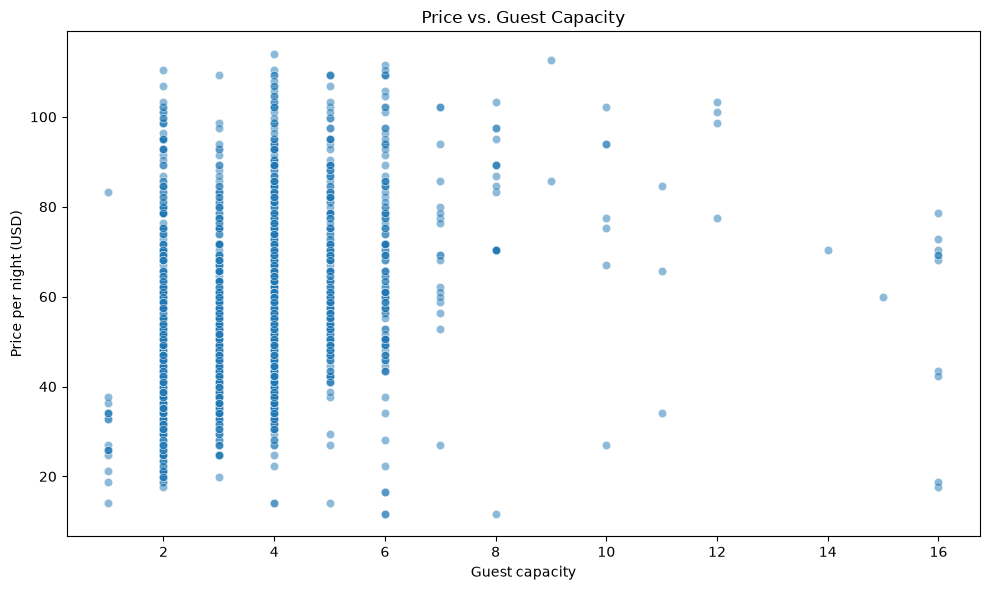

In [65]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="personcapacity",
    y="basicnightprice_usd",
    alpha=0.5,
)

plt.title(
    "Price vs. Guest Capacity"
)
plt.xlabel("Guest capacity")
plt.ylabel("Price per night (USD)")

plt.tight_layout()
plt.show()

### Interpretation

The analysis shows a positive relationship between guest
capacity and nightly price.

The correlation coefficient is approximately 0.30, which
indicates a moderate positive relationship.

This suggests that listings capable of accommodating more
guests tend to have higher nightly prices.

## Neighbourhood Analysis

Location is an important factor in accommodation pricing.

The dataset contains neighbourhood information for a subset
of listings. To avoid misleading conclusions based on
neighbourhoods with only one or two listings, only
neighbourhoods with at least 10 listings are included in
the main comparison.

In [66]:
neighbourhood_results = price_by_neighbourhood(df)

neighbourhood_results = (
    neighbourhood_results[
        neighbourhood_results["listings"] >= 10
    ]
)

neighbourhood_results

,listings,average_price,median_price,average_rating
neighbourhood,,,,
Серава,10,55.55200,54.61,4.880000
Cheshma,156,49.76359,46.39,4.773058


In [67]:
top_neighbourhoods = (
    neighbourhood_results
    .sort_values(
        "average_price",
        ascending=False,
    )
    .head(15)
)

top_neighbourhoods

,listings,average_price,median_price,average_rating
neighbourhood,,,,
Серава,10,55.55200,54.61,4.880000
Cheshma,156,49.76359,46.39,4.773058


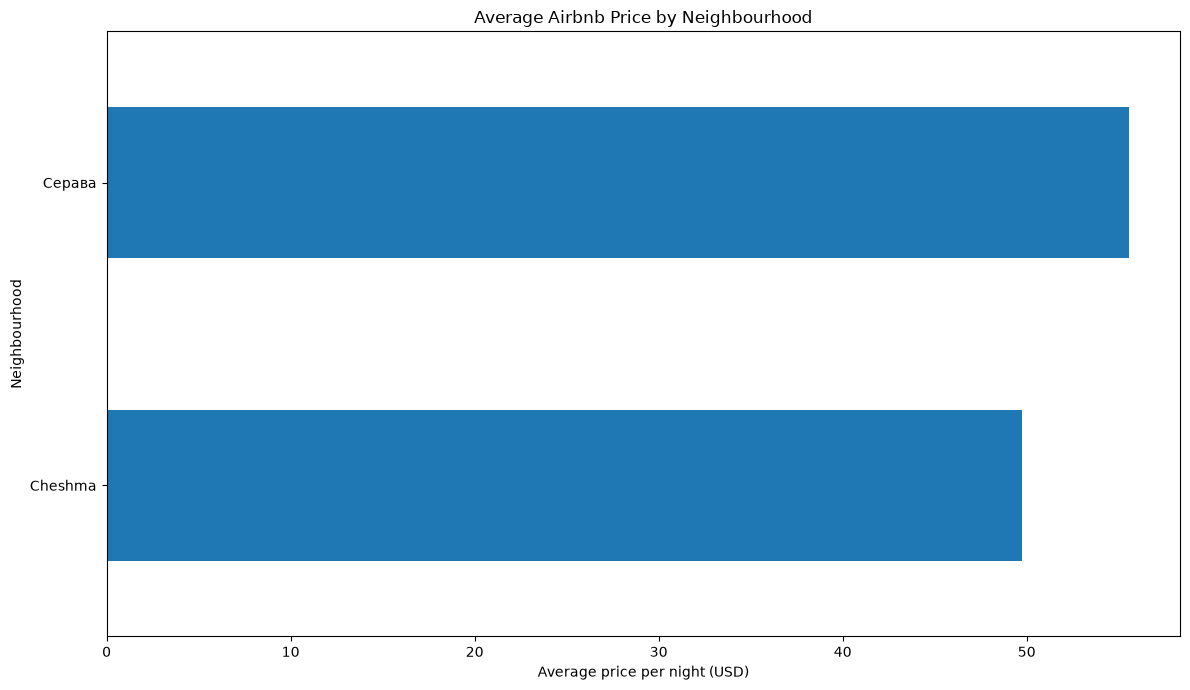

In [68]:
plt.figure(figsize=(12, 7))

top_neighbourhoods[
    "average_price"
].sort_values().plot(
    kind="barh"
)

plt.title(
    "Average Airbnb Price by Neighbourhood"
)
plt.xlabel("Average price per night (USD)")
plt.ylabel("Neighbourhood")

plt.tight_layout()
plt.show()

### Interpretation

The average Airbnb price differs between neighbourhoods.

However, the results should be interpreted with caution
because the number of listings is not equal across all
neighbourhoods.

For this reason, neighbourhoods with fewer than 10 listings
were excluded from the main comparison.

## Best Value Airbnb Listings

A high rating alone does not necessarily indicate good value.

To identify potentially attractive listings, we combine
three factors:

- rating
- number of reviews
- nightly price

Only listings with a rating of at least 4.5 and at least
5 reviews are considered.

A simple value score is calculated as:

    value score = rating / price

Higher values indicate a combination of relatively high
ratings and relatively low prices.

In [69]:
best_value = best_value_listings(
    df,
    minimum_rating=4.5,
    minimum_reviews=5,
    number=20,
)

best_value

,listingtitle,basicnightprice_usd,starrating,reviewcount,roomtype_clean,value_score
538,Bed in 6 bedroom mixed dormitory,11.74,4.96,28,Shared Room,0.422487
2104,Single room at the Pioneers,14.09,4.89,18,Private Room,0.347055
1324,Bed in 4-bed mix room in a Hostel,14.09,4.87,23,Shared Room,0.345635
1593,The Pioneers Home,14.09,4.50,38,Private Room,0.319375
574,Mickitos Urban Hostel / Bed in a dorm room,17.62,4.75,51,Shared Room,0.269580
1831,R&K Hostel - in the city center,18.79,5.00,7,Shared Room,0.266099
1648,Cash Room,19.97,5.00,18,Private Room,0.250376
524,Apartment 33,18.79,4.58,26,Entire Home,0.243747
220,Madzovski,19.97,4.80,5,Private Room,0.240361
1438,Cosy and quiet place!,19.97,4.76,21,Private Room,0.238358


In [70]:
best_value_display = best_value.copy()

best_value_display[
    "basicnightprice_usd"
] = best_value_display[
    "basicnightprice_usd"
].round(2)

best_value_display[
    "starrating"
] = best_value_display[
    "starrating"
].round(2)

best_value_display[
    "value_score"
] = best_value_display[
    "value_score"
].round(3)

best_value_display

,listingtitle,basicnightprice_usd,starrating,reviewcount,roomtype_clean,value_score
538,Bed in 6 bedroom mixed dormitory,11.74,4.96,28,Shared Room,0.422
2104,Single room at the Pioneers,14.09,4.89,18,Private Room,0.347
1324,Bed in 4-bed mix room in a Hostel,14.09,4.87,23,Shared Room,0.346
1593,The Pioneers Home,14.09,4.50,38,Private Room,0.319
574,Mickitos Urban Hostel / Bed in a dorm room,17.62,4.75,51,Shared Room,0.270
1831,R&K Hostel - in the city center,18.79,5.00,7,Shared Room,0.266
1648,Cash Room,19.97,5.00,18,Private Room,0.250
524,Apartment 33,18.79,4.58,26,Entire Home,0.244
220,Madzovski,19.97,4.80,5,Private Room,0.240
1438,Cosy and quiet place!,19.97,4.76,21,Private Room,0.238


### Interpretation

The best-value analysis identifies listings that combine
relatively low prices with high ratings and a minimum level
of review activity.

This ranking should not be interpreted as an official Airbnb
quality ranking. Instead, it is a simple analytical measure
created specifically for this project.

## Correlation Analysis

Correlation analysis is used to investigate linear
relationships between numerical variables.

The matrix includes variables related to:

- price
- guest capacity
- bedrooms
- beds
- reviews
- ratings
- service quality

In [71]:
correlation = correlation_analysis(df)

correlation

,basicnightprice_usd,price_per_guest,price_per_bedroom,personcapacity,bedrooms,beds,reviewcount,starrating,locationrating,cleanlinessrating,valuerating,accuracyrating,checkinrating,communicationrating
basicnightprice_usd,1.000000,0.457976,0.514112,0.296619,0.161079,0.149427,-0.090163,0.006977,0.063128,0.014999,0.008749,0.008562,-0.016577,-0.023090
price_per_guest,0.457976,1.000000,0.623032,-0.540298,-0.156071,-0.157879,-0.098117,0.065020,0.127109,0.062709,0.058453,0.057443,0.037582,0.029087
price_per_bedroom,0.514112,0.623032,1.000000,-0.268285,-0.420961,-0.420961,-0.082284,0.056220,0.115486,0.054785,0.031866,0.039704,0.006916,-0.017023
personcapacity,0.296619,-0.540298,-0.268285,1.000000,0.478203,0.469083,0.027499,-0.066660,-0.079069,-0.064063,-0.053070,-0.062691,-0.043040,-0.028687
bedrooms,0.161079,-0.156071,-0.420961,0.478203,1.000000,1.000000,-0.004656,-0.078914,-0.056506,-0.081058,-0.064280,-0.071730,-0.039356,-0.022941
beds,0.149427,-0.157879,-0.420961,0.469083,1.000000,1.000000,0.010279,-0.078758,-0.054473,-0.082992,-0.064856,-0.073973,-0.038550,-0.021463
reviewcount,-0.090163,-0.098117,-0.082284,0.027499,-0.004656,0.010279,1.000000,0.093442,0.056425,0.087965,0.102322,0.094818,0.079483,0.093854
starrating,0.006977,0.065020,0.056220,-0.066660,-0.078914,-0.078758,0.093442,1.000000,0.678643,0.867427,0.887526,0.864407,0.751455,0.789665
locationrating,0.063128,0.127109,0.115486,-0.079069,-0.056506,-0.054473,0.056425,0.678643,1.000000,0.628689,0.696334,0.672823,0.643183,0.537879
cleanlinessrating,0.014999,0.062709,0.054785,-0.064063,-0.081058,-0.082992,0.087965,0.867427,0.628689,1.000000,0.812123,0.771798,0.652146,0.662153


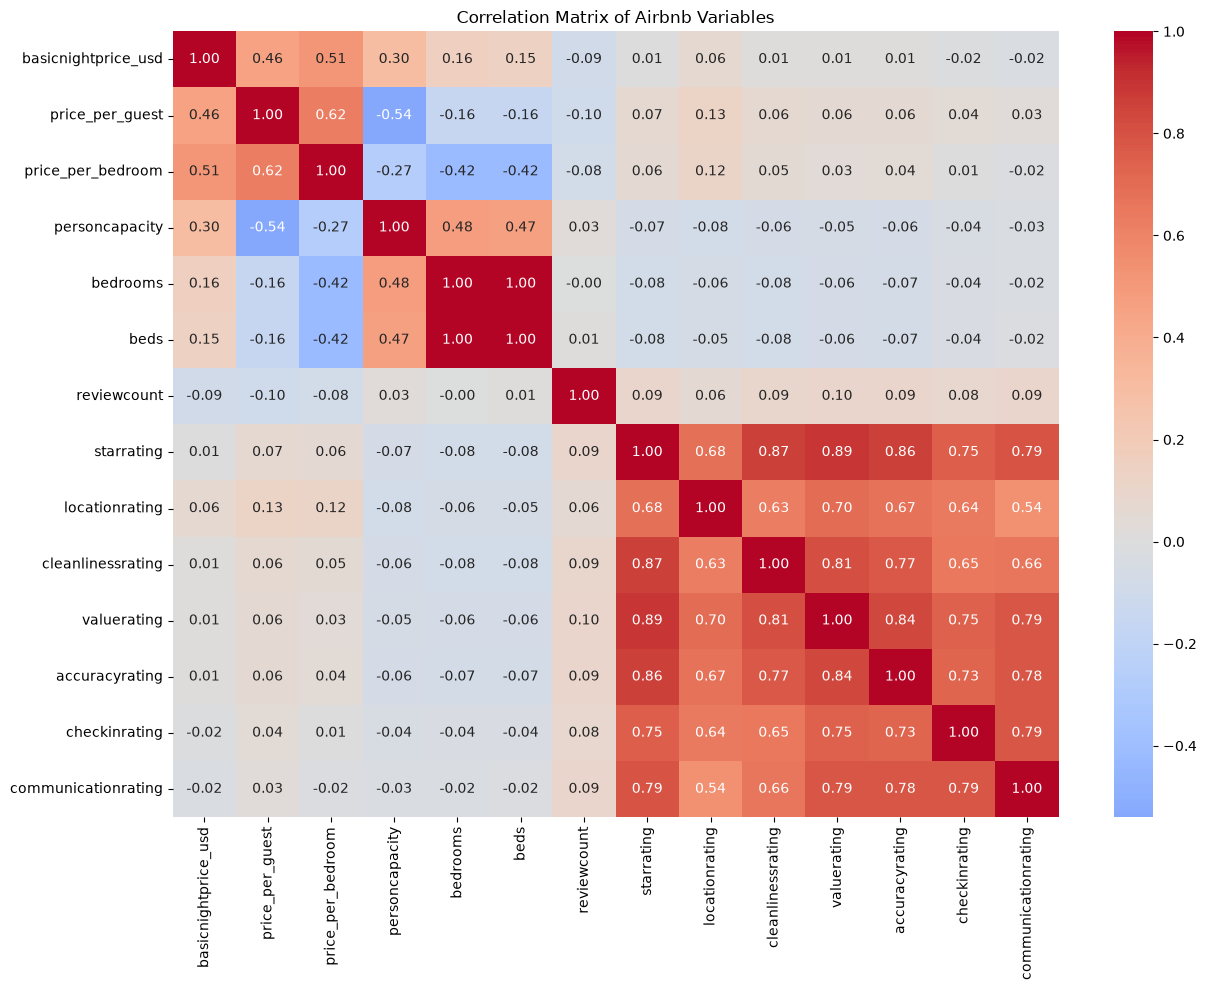

In [72]:
plt.figure(figsize=(13, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)

plt.title(
    "Correlation Matrix of Airbnb Variables"
)

plt.tight_layout()
plt.show()

### Interpretation

The correlation matrix shows that price has a moderate
positive relationship with guest capacity and price per
bedroom.

The relationship between nightly price and overall rating
is very weak.

Ratings for different aspects of the Airbnb experience,
such as communication, check-in and value, are strongly
positively correlated with one another.

Correlation does not imply causation, so these results
describe statistical relationships rather than causal effects.